# 07 — Handmade features + K-Means

Пайплайн: `Dataloader` → окна с индикаторами → `HandmadeEmbedder` (16 статистик на окно) → **KMeansClusterer** → интерпретация через `cluster_analysis` и `ClusterAnalyzer`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from embeddings.Handmade_embedder import HandmadeEmbedder, FEATURE_NAMES
from clustering.kmeans import KMeansClusterer
from clustering.cluster_analysis import elbow_scores, plot_elbow, plot_clusters_2d, cluster_stats
from clustering.cluster_analyze import ClusterAnalyzer

WINDOW_SIZE = 60   # 60 торговых дней ≈ 1 квартал — минимум для надёжных skew/kurtosis
STEP = 20          # 67% overlap → ~30K окон; STEP=60 (нахлёст 0%) — чище, но таймлайн слишком редкий
RANDOM_STATE = 42
K_RANGE = range(2, 11)  # тестируем ВСЕ k от 2 до 10; финансовые режимы обычно 3–6
np.random.seed(RANDOM_STATE)

print(f"Tickers: {len(TICKERS)}  |  Window: {WINDOW_SIZE}  |  Step: {STEP}")
print(f"Handmade features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

245
Tickers: 245  |  Window: 60  |  Step: 20
Handmade features (15): ['slope', 'net_move', 'frac_above_mean', 'price_range', 'daily_vol', 'skewness', 'kurtosis', 'price_vol_corr', 'vol_activity', 'last_rsi', 'last_macd_hist', 'last_bb_pct', 'last_bb_bw', 'rsi_slope', 'macd_slope']


In [2]:
loader = Dataloader()

FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]
CLOSE_IDX = FEATURE_COLS.index("close")

dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=WINDOW_SIZE,
    step_size=STEP,
    feature_cols=FEATURE_COLS,
    add_indicators=True,
    path="../../src/data/moex_candles",
)
print(f"Loaded {len(dataset)} / {len(TICKERS)} tickers")

X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loaded 236 / 245 tickers
X_train: (28673, 60, 18)  y_train: (28673,)
X_val:   (5039, 60, 18)    y_val:   (5039,)
X_test:  (3698, 60, 18)   y_test:  (3698,)


In [3]:
embedder = HandmadeEmbedder()

train_emb_raw = embedder.transform(X_train)
val_emb_raw   = embedder.transform(X_val)
test_emb_raw  = embedder.transform(X_test)

# Убираем строки с NaN/Inf (появляются на вырожденных окнах)
def clean_mask(emb: np.ndarray) -> np.ndarray:
    return np.isfinite(emb).all(axis=1)

mask_tr   = clean_mask(train_emb_raw)
mask_val  = clean_mask(val_emb_raw)
mask_test = clean_mask(test_emb_raw)

train_emb = train_emb_raw[mask_tr]
val_emb   = val_emb_raw[mask_val]
test_emb  = test_emb_raw[mask_test]

X_train, y_train = X_train[mask_tr],   y_train[mask_tr]
X_val,   y_val   = X_val[mask_val],     y_val[mask_val]
X_test,  y_test  = X_test[mask_test],   y_test[mask_test]

print(f"Train: {train_emb_raw.shape[0]:,} → {train_emb.shape[0]:,}  (dropped {(~mask_tr).sum():,})")
print(f"Val:   {val_emb_raw.shape[0]:,} → {val_emb.shape[0]:,}  (dropped {(~mask_val).sum():,})")
print(f"Test:  {test_emb_raw.shape[0]:,} → {test_emb.shape[0]:,}  (dropped {(~mask_test).sum():,})")

Train: 28,673 → 28,673  (dropped 0)
Val:   5,039 → 5,039  (dropped 0)
Test:  3,698 → 3,698  (dropped 0)


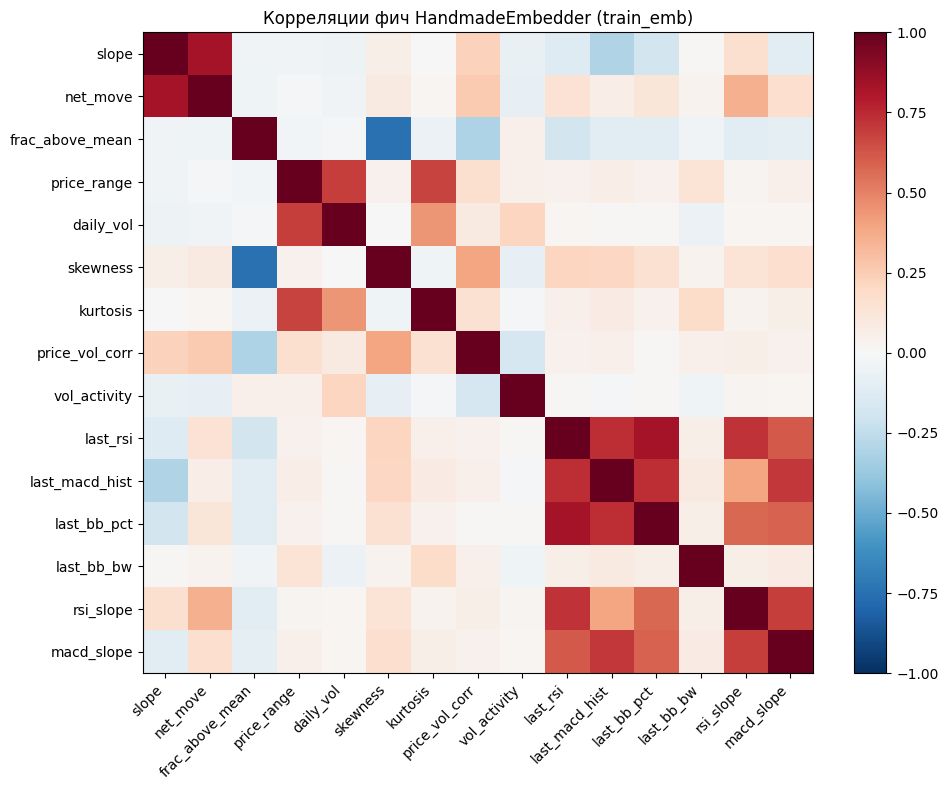

Пары с |r| ≥ 0.85:
  (нет таких пар)


In [4]:
# Диагностика мультиколлинеарности (до elbow / KMeans)
CORR_THRESH = 0.85

emb_df = pd.DataFrame(train_emb, columns=FEATURE_NAMES)
C = emb_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
ax.set_yticklabels(FEATURE_NAMES)
plt.colorbar(im, ax=ax)
ax.set_title("Корреляции фич HandmadeEmbedder (train_emb)")
plt.tight_layout()
plt.show()

pairs = []
n = len(FEATURE_NAMES)
for i in range(n):
    for j in range(i + 1, n):
        r = float(C.iloc[i, j])
        if abs(r) >= CORR_THRESH:
            pairs.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))
pairs.sort(key=lambda x: -abs(x[2]))
print(f"Пары с |r| ≥ {CORR_THRESH}:")
for a, b, r in pairs:
    print(f"  {a} ↔ {b}:  r = {r:.4f}")
if not pairs:
    print("  (нет таких пар)")

Elbow: подвыборка 10,000 из 28,673 окон


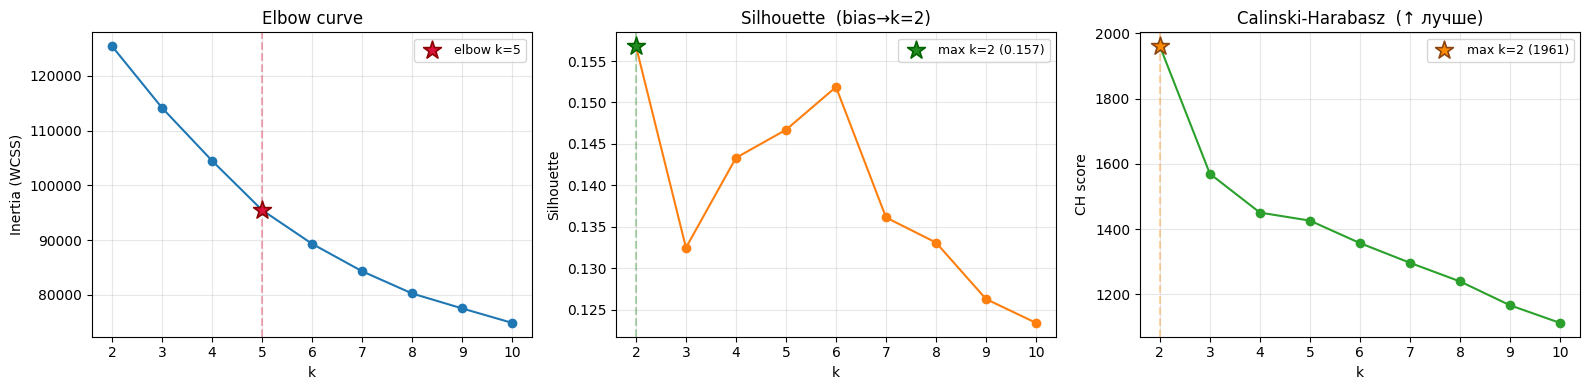


Метрика                  k
Elbow (inertia)          5
Max Silhouette           2  (bias → k=2!)
Max Calinski-Harabasz    2

→ BEST_K = 5  (правь вручную если нужно)


In [5]:
# ─── Выбор k: три метрики ────────────────────────────────────────────────────
# Silhouette имеет структурный bias к k=2 на финансовых данных (непрерывные
# распределения без чётких "гауссовых сгустков"). Поэтому смотрим ВСЕ три:
#   • Elbow (inertia) — геометрический ориентир
#   • Silhouette      — compactness/separation (biased → k=2)
#   • Calinski-Harabasz — between/within variance ratio (менее biased)
# Принимай k, которое согласуется хотя бы в двух метриках.
# Для режимов рынка доменное знание: обычно 3–5 режимов.
# ─────────────────────────────────────────────────────────────────────────────

# Silhouette O(n²): при n > 20_000 подвыборка ускоряет без потери точности.
ELBOW_SUBSAMPLE = 10_000  # None = весь train
ELBOW_N_JOBS = -1

rng = np.random.default_rng(RANDOM_STATE)
emb_elbow = train_emb
if ELBOW_SUBSAMPLE is not None and len(train_emb) > ELBOW_SUBSAMPLE:
    idx = rng.choice(len(train_emb), size=ELBOW_SUBSAMPLE, replace=False)
    emb_elbow = train_emb[idx]
    print(f"Elbow: подвыборка {ELBOW_SUBSAMPLE:,} из {len(train_emb):,} окон")
else:
    print(f"Elbow: все {len(train_emb):,} окон")

scores = plot_elbow(
    emb_elbow,
    k_range=K_RANGE,
    scale=True,
    random_state=RANDOM_STATE,
    n_jobs=ELBOW_N_JOBS,
)

k_elbow = scores["k_elbow"]
k_sil   = scores["k_silhouette_max"]
k_ch    = scores["k_calinski_max"]

print(f"\n{'Метрика':<22} {'k':>3}")
print(f"{'Elbow (inertia)':<22} {k_elbow:>3}")
print(f"{'Max Silhouette':<22} {k_sil:>3}  (bias → k=2!)")
print(f"{'Max Calinski-Harabasz':<22} {k_ch:>3}")

# Для рынка берём k от CH, если он != 2, иначе — от elbow.
# Но можно и зафиксировать вручную:
BEST_K = k_ch if k_ch and k_ch > 2 else k_elbow
print(f"\n→ BEST_K = {BEST_K}  (правь вручную если нужно)")

In [6]:
km = KMeansClusterer(n_clusters=BEST_K, random_state=RANDOM_STATE, scale=True, n_init=10)
km.fit(train_emb)

labels_train = km.labels_
labels_val   = km.predict(val_emb)
labels_test  = km.predict(test_emb)

print(f"Inertia (WCSS): {km.inertia_:.2f}")
for c in range(BEST_K):
    print(f"  C{c}: {(labels_train == c).sum():,} train windows")

Inertia (WCSS): 278621.88
  C0: 8,271 train windows
  C1: 8,077 train windows
  C2: 7,150 train windows
  C3: 190 train windows
  C4: 4,985 train windows


,count,return_mean,return_std,return_median,pct
cluster,,,,,
0,8271,-13126.320015,1.193628e+06,-1.349317,28.845953
1,8077,-2.649599,2.151684e+02,-1.460523,28.169358
2,7150,-1.269303,2.283439e+01,-1.530734,24.936351
3,190,-3.027834,2.126156e+01,-1.134175,0.662644
4,4985,31894.710094,1.617391e+06,-2.221809,17.385694


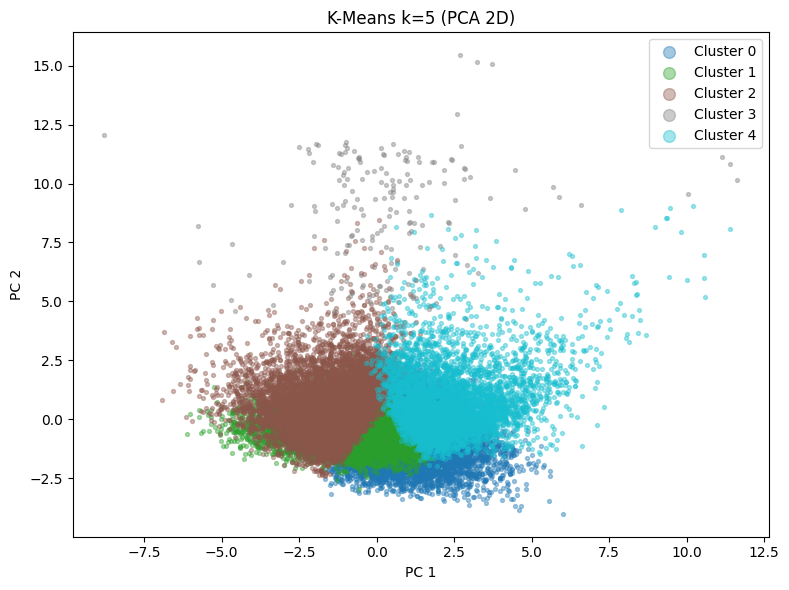

In [7]:
# Таблица размеров / средних return по кластерам (cluster_analysis)
def window_simple_returns(X: np.ndarray, close_idx: int) -> np.ndarray:
    close = X[:, :, close_idx].astype(float)
    return close[:, -1] / (close[:, 0] + 1e-8) - 1.0

ret_train = window_simple_returns(X_train, CLOSE_IDX)
stats_df = cluster_stats(labels_train, returns=ret_train)
display(stats_df)

plot_clusters_2d(train_emb, labels_train, scale=True, title=f"K-Means k={BEST_K} (PCA 2D)")

In [8]:
def window_ends_for_split(
    loader: Dataloader,
    dataset: dict,
    split: str,
    seq_len: int,
    step: int,
    horizon: int = 1,
):
    """Для каждого окна: тикер и timestamp последнего бара окна.
    Порядок строк = concat_splits(dataset). Окна с NaN в y (как в make_windows) пропущены.
    После эмбеддера примени mask_tr: tickers_tr, ts_tr = ...[mask_tr]."""
    tickers_out, ts_out = [], []
    for ticker, splits in dataset.items():
        X_part, y_part = splits[split]
        if len(X_part) == 0:
            continue
        df = loader.load_df(ticker)
        if df is None:
            continue
        df = loader.add_features(df)
        tr, va, te = loader.split_df(df)
        sdf = {"train": tr, "val": va, "test": te}[split]
        if len(sdf) < seq_len + horizon:
            continue
        fcols = [c for c in FEATURE_COLS if c in sdf.columns]
        if "close" not in fcols:
            fcols = ["close"] + fcols
        close_all = sdf["close"].values.astype(np.float32)
        collected = []
        for start in range(0, len(sdf) - seq_len - horizon + 1, step):
            end = start + seq_len
            close_last = close_all[end - 1]
            close_next = close_all[end - 1 + horizon]
            target = (
                np.log(close_next / close_last)
                if close_last > 0 and close_next > 0
                else np.nan
            )
            if not np.isnan(target):
                collected.append((ticker, sdf.index[end - 1]))
        if len(collected) != len(X_part):
            raise RuntimeError(
                f"Mismatch {ticker} {split}: windows {len(X_part)} vs meta {len(collected)}"
            )
        for t, ts in collected:
            tickers_out.append(t)
            ts_out.append(ts)
    return np.array(tickers_out, dtype=object), np.array(ts_out)


tickers_tr, ts_tr = window_ends_for_split(
    loader, dataset, "train", WINDOW_SIZE, STEP
)
# X_train / labels_train после clean_mask короче полного concat_splits
assert len(tickers_tr) == len(mask_tr)
tickers_tr, ts_tr = tickers_tr[mask_tr], ts_tr[mask_tr]
assert len(tickers_tr) == len(labels_train) == len(X_train)
print(f"Metadata train: {len(ts_tr)} window ends (после mask_tr, как X_train)")

Metadata train: 28673 window ends (после mask_tr, как X_train)


══════════════════════════════════════════════════════════
  ClusterAnalyzer
  5 кластеров · 28,673 валидных окон · 0 шум
══════════════════════════════════════════════════════════

── Метрики качества кластеризации ──────────────────────


,value,interpretation,note
metric,,,
Silhouette Score,0.1436,↑ лучше (−1 … +1),"n=28,673"
Davies-Bouldin Index,1.7497,↓ лучше (≥ 0),"n=28,673"
Calinski-Harabasz Index,3896.3600,↑ лучше (≥ 0),"n=28,673"
Noise ratio,0.0000,↓ лучше (%),"0 / 28,673 точек"
N clusters,5.0000,—,без шума



[1/7] 2D scatter эмбеддингов…
[2/7] Средние профили окон…
[3/7] Статистики кластеров…
[4/7] Тепловая карта признаков…
[5/7] Распределение returns…
[6/7] Временное распределение…
[7/7] Матрица переходов…

══════════════════════════════════════════════════════════
  Готово. Фигуры доступны в возвращённом словаре.
══════════════════════════════════════════════════════════


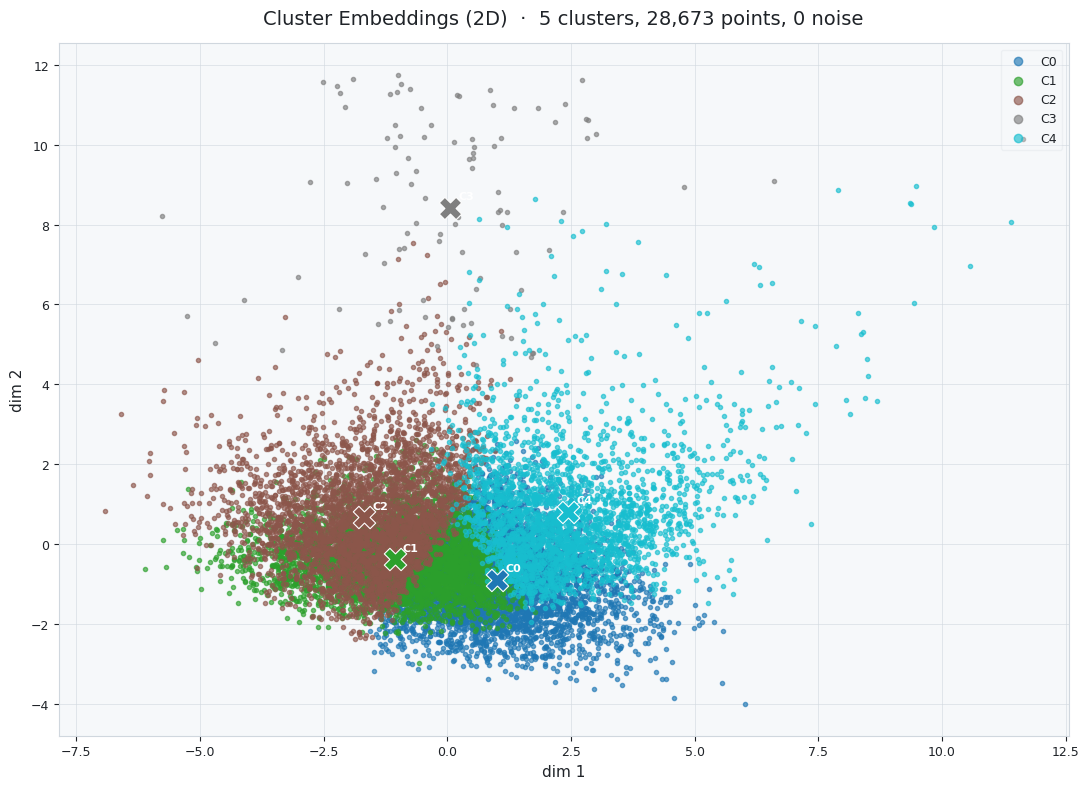

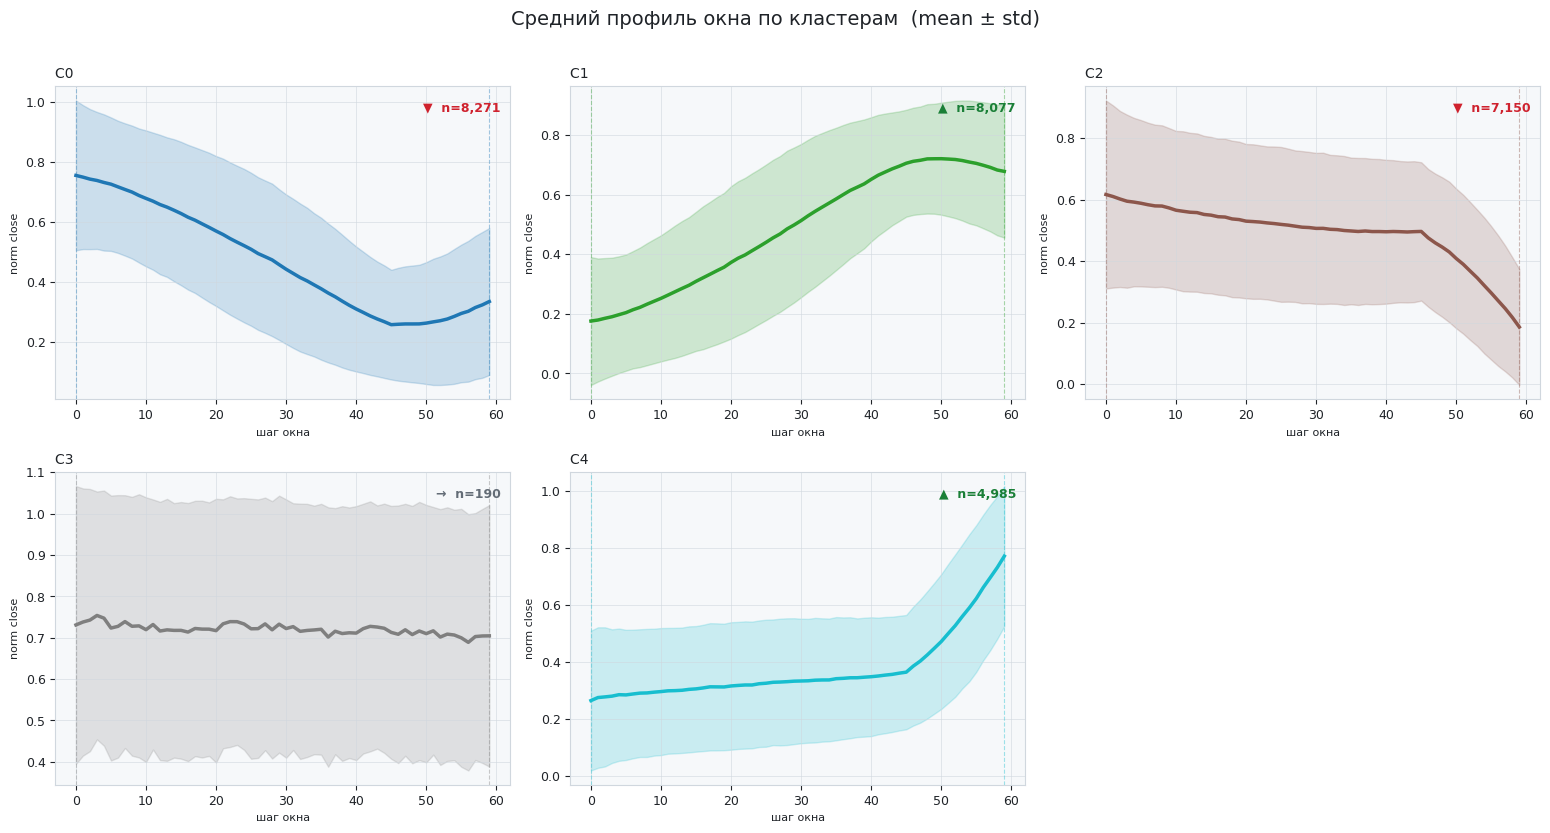

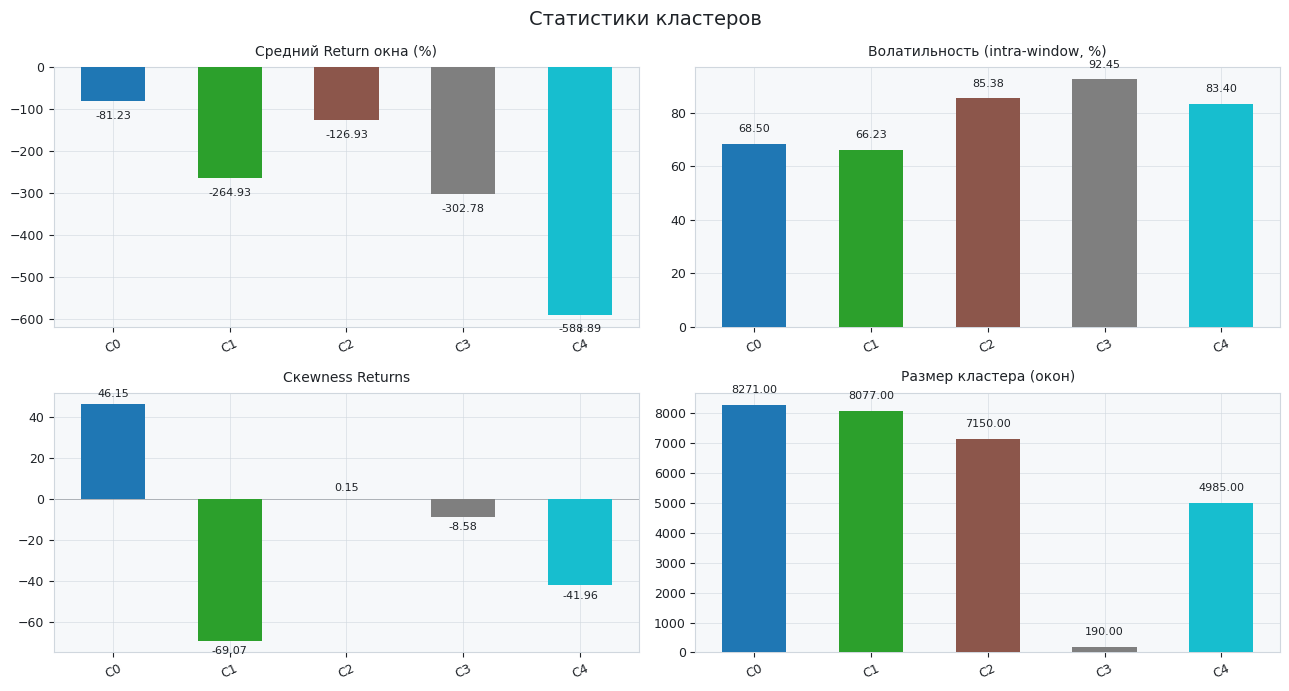

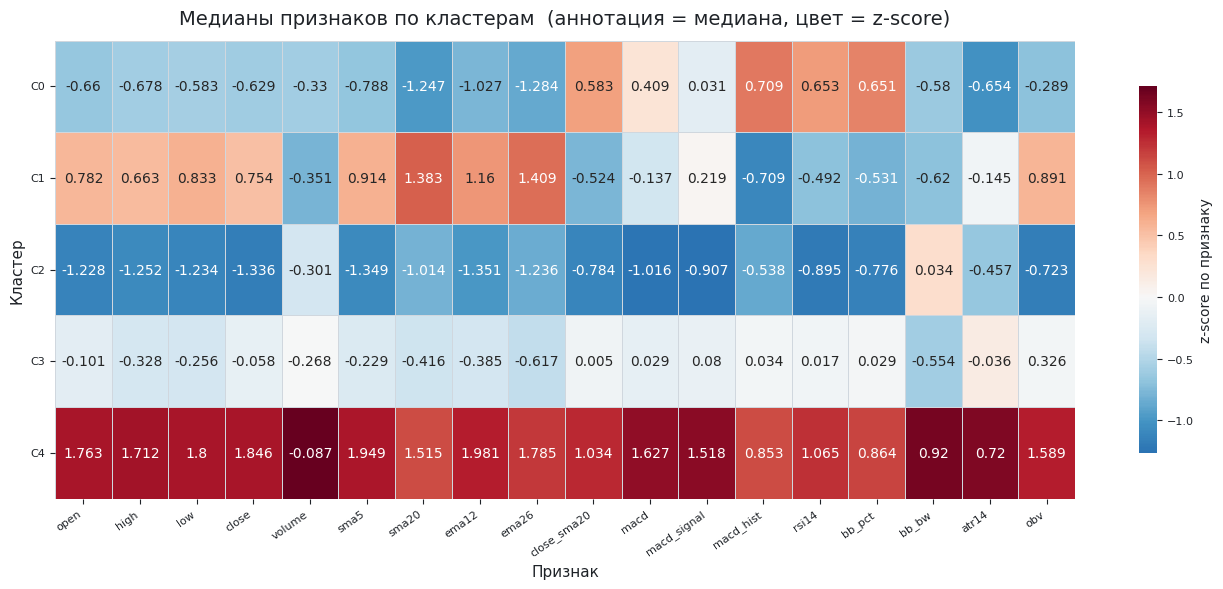

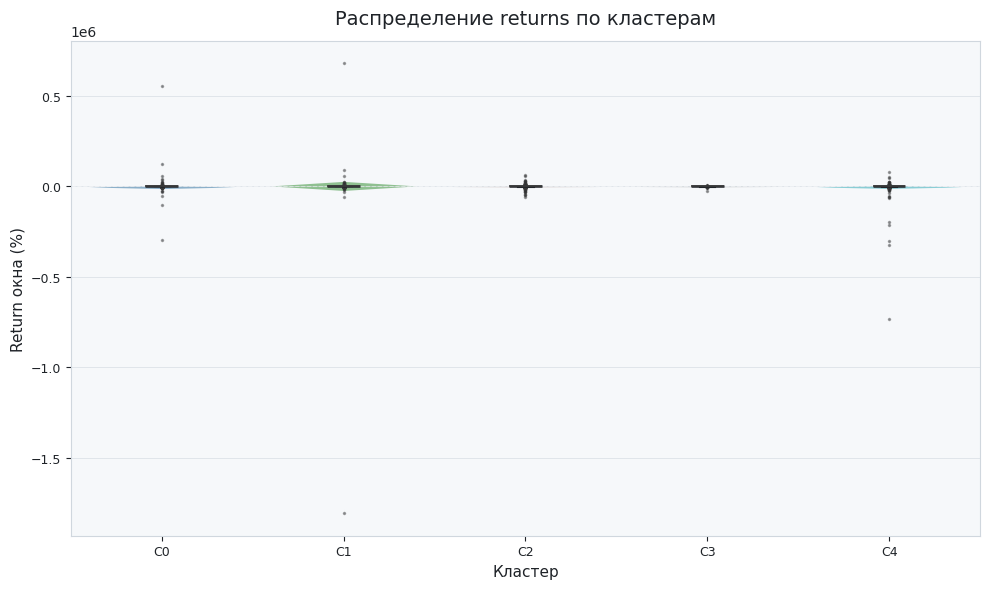

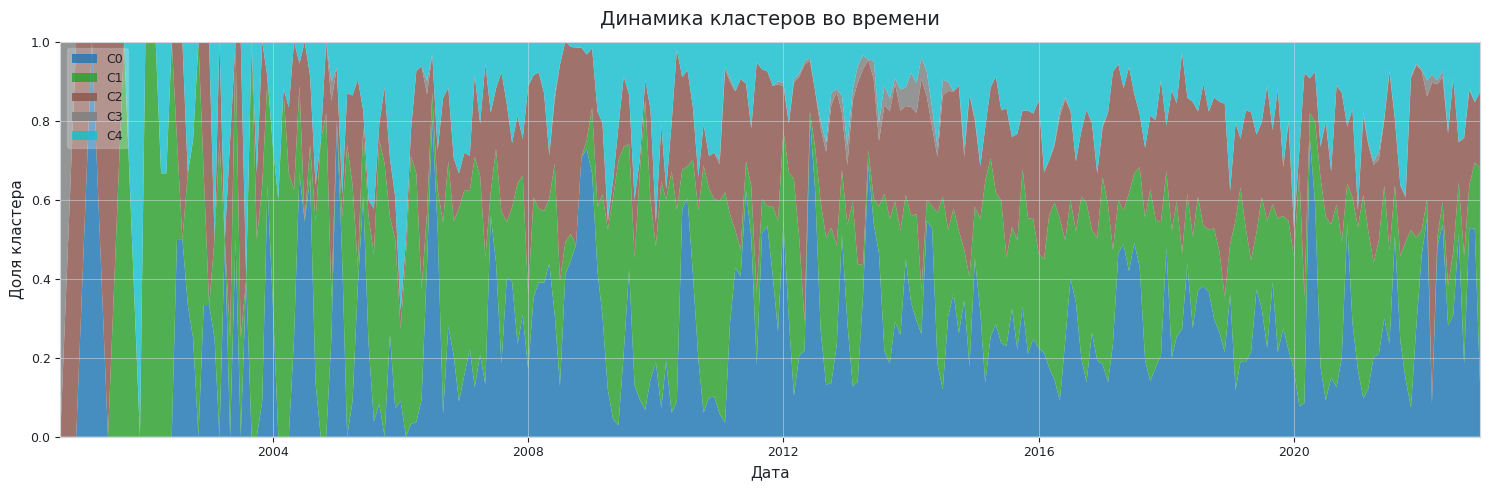

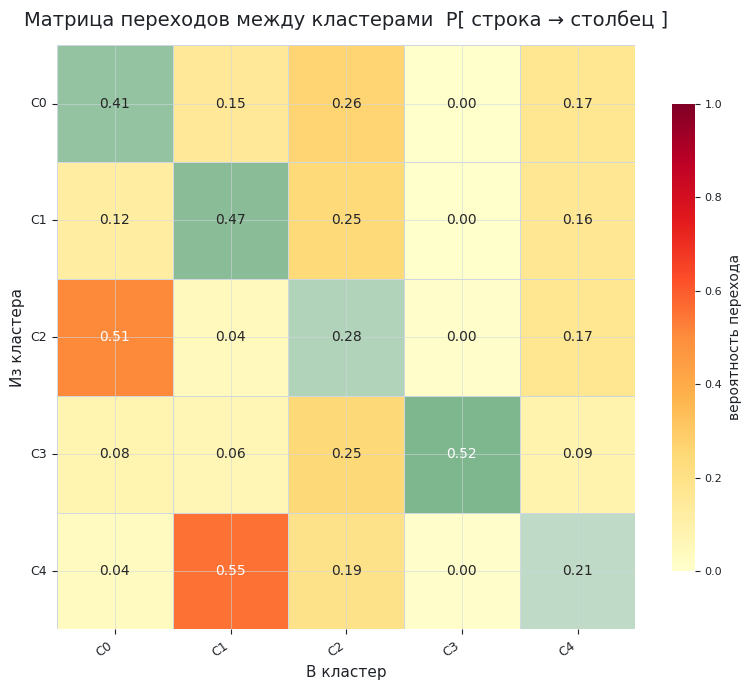

In [9]:
# Интерпретация: ClusterAnalyzer (метрики + графики)
# X_metrics = Z — то же масштабирование, что внутри KMeansClusterer (StandardScaler на train)
Z_train = StandardScaler().fit_transform(train_emb)
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d = pca_vis.fit_transform(Z_train)

analyzer = ClusterAnalyzer(
    labels=labels_train,
    windows=X_train,
    embeddings=train_emb,
    timestamps=ts_tr,
    tickers=tickers_tr,
    close_idx=CLOSE_IDX,
    feature_names=FEATURE_COLS,
)

figs = analyzer.run_all(
    embeddings_2d=emb_2d,
    X_metrics=Z_train,
    max_tickers=8,
    aggregate_temporal=True,
)
plt.show()